# **Task 3: Energy Consumption Time Series Forecasting**

## **1. Problem Statement and Objective**

### Problem Statement

Household electricity consumption changes over time because of daily routines, weekends, seasonal behavior, and usage patterns. Accurately forecasting short-term energy usage can help households, energy companies, and grid managers plan electricity demand more efficiently.

### Objective

The objective of this task is to forecast short-term household energy consumption using historical time-series data.

This notebook will:

1. Load the Household Power Consumption Dataset.
2. Parse date and time columns correctly.
3. Clean missing and invalid values.
4. Resample the data into hourly energy usage.
5. Engineer time-based features such as hour, day, month, and weekend indicator.
6. Train and compare three forecasting models:

   * ARIMA
   * Prophet
   * XGBoost
7. Evaluate models using MAE, RMSE, and MAPE.
8. Plot actual vs forecasted energy usage.
9. Provide final insights and conclusions.

### Install Required Libraries

In [1]:
!pip install prophet xgboost statsmodels -q

### Import Libraries

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Time series and machine learning models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# **2. Dataset Description and Loading**

### **Dataset Description**

The **Household Power Consumption Dataset** contains minute-level electricity consumption data from a household.

Common columns include:

| Column                | Description                                              |
| --------------------- | -------------------------------------------------------- |
| Date                  | Date of observation                                      |
| Time                  | Time of observation                                      |
| Global_active_power   | Total active power consumed by the household             |
| Global_reactive_power | Reactive power consumption                               |
| Voltage               | Household voltage                                        |
| Global_intensity      | Current intensity                                        |
| Sub_metering_1        | Energy used in kitchen                                   |
| Sub_metering_2        | Energy used in laundry room                              |
| Sub_metering_3        | Energy used by electric water heater and air conditioner |

For this task, the main target variable is:

**Global_active_power**

This represents the total household active power consumption.

### Download and Extract Dataset

In [3]:
import zipfile
import requests
import os

# Dataset URL from UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip"

zip_path = "household_power_consumption.zip"

# Download dataset
response = requests.get(url)

with open(zip_path, "wb") as file:
    file.write(response.content)

# Extract zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("household_power_consumption")

# Check extracted files
os.listdir("household_power_consumption")

['household_power_consumption.txt']

### Load Dataset

In [4]:
# Load dataset
file_path = "household_power_consumption/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

# Display first five rows
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# **3. Initial Dataset Exploration**

## Basic Information

In [5]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2075259
Number of columns: 9


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [7]:
# First few rows
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
# Statistical summary
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


---

## Check Missing Values

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_values

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


---

# **4. Data Cleaning and Preprocessing**

## Combine Date and Time Columns

In [10]:
# Combine Date and Time into one datetime column
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

# Drop original Date and Time columns
df = df.drop(columns=["Date", "Time"])

# Set datetime as index
df = df.set_index("datetime")

# Sort by datetime index
df = df.sort_index()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


---

## Convert Columns to Numeric

In [11]:
# Convert all columns to numeric
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Check data types
df.dtypes

,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


---

## Handle Missing Values

In [12]:
# Check missing values again
df.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [13]:
# Fill missing values using forward fill
df = df.ffill()

# If any missing values still remain, use backward fill
df = df.bfill()

# Confirm missing values are handled
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


---

# **5. Parse and Resample Time Series Data**

The original dataset is recorded at **minute-level frequency**.
For short-term forecasting, we will resample it into **hourly average energy usage**.

This makes the data easier to model and reduces computational cost.

---

## Resample Data Hourly

In [14]:
# Resample Global Active Power into hourly average consumption
hourly_df = df[["Global_active_power"]].resample("H").mean()

# Rename target column
hourly_df = hourly_df.rename(columns={
    "Global_active_power": "energy_consumption"
})

# Fill any missing values after resampling
hourly_df = hourly_df.ffill().bfill()

hourly_df.head()

,energy_consumption
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [15]:
# Check resampled data shape
print("Hourly dataset shape:", hourly_df.shape)
print("Start date:", hourly_df.index.min())
print("End date:", hourly_df.index.max())

Hourly dataset shape: (34589, 1)
Start date: 2006-12-16 17:00:00
End date: 2010-11-26 21:00:00


# **6. Exploratory Data Analysis**

## Plot Overall Energy Consumption

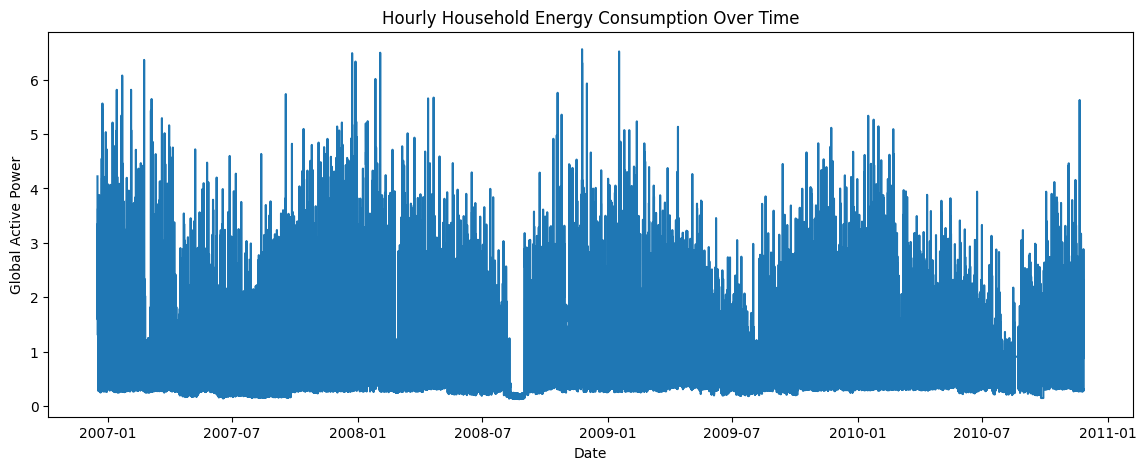

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(hourly_df.index, hourly_df["energy_consumption"])
plt.title("Hourly Household Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()

---

## Plot One Month of Energy Consumption

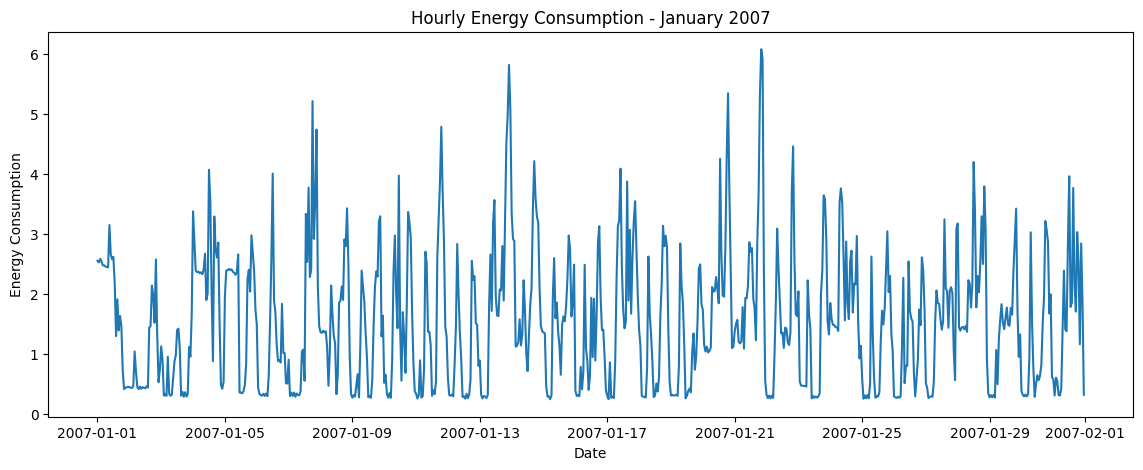

In [17]:
# Plot one month to better observe patterns
one_month = hourly_df.loc["2007-01-01":"2007-01-31"]

plt.figure(figsize=(14, 5))
plt.plot(one_month.index, one_month["energy_consumption"])
plt.title("Hourly Energy Consumption - January 2007")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.show()

---

## Daily Average Energy Consumption

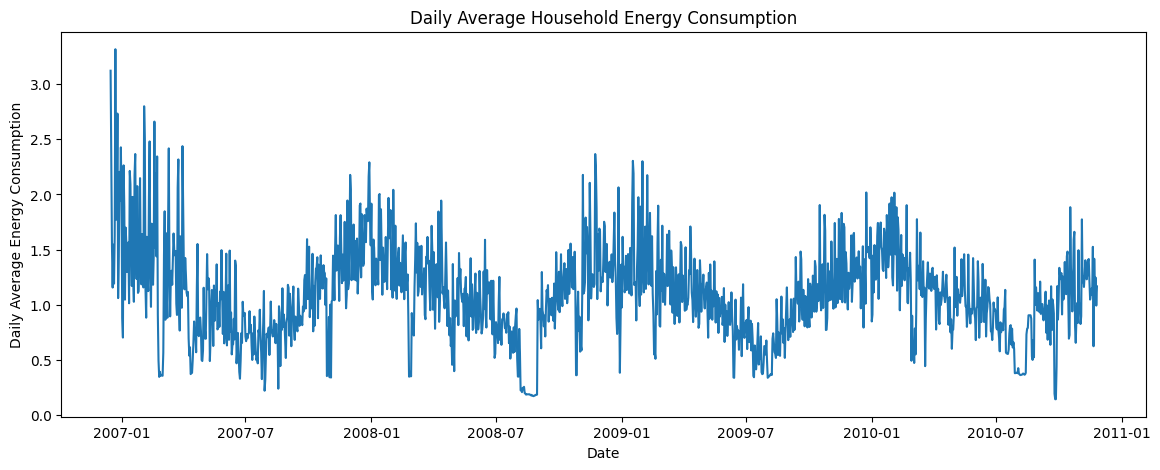

In [18]:
daily_df = hourly_df.resample("D").mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_df.index, daily_df["energy_consumption"])
plt.title("Daily Average Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Daily Average Energy Consumption")
plt.show()

---

## Monthly Average Energy Consumption

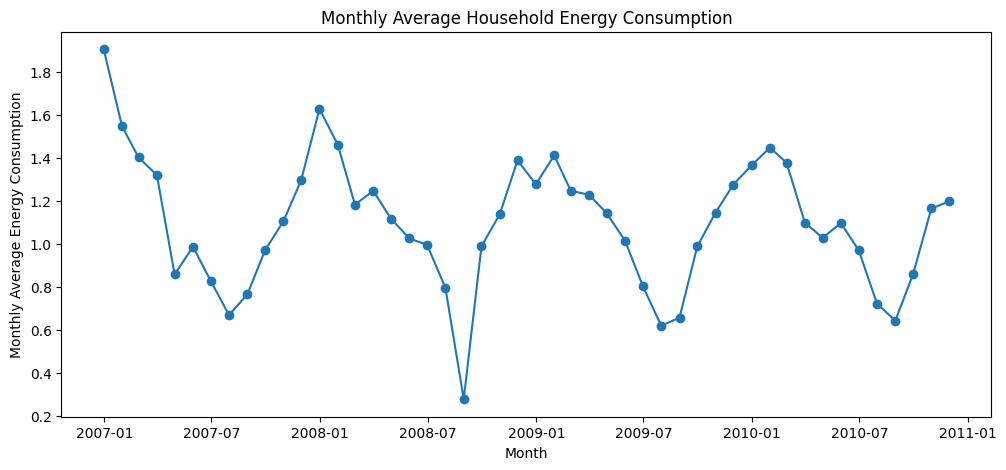

In [19]:
monthly_df = hourly_df.resample("M").mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df["energy_consumption"], marker="o")
plt.title("Monthly Average Household Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Monthly Average Energy Consumption")
plt.show()

---

# **7. Time-Based Feature Engineering**

We will create time-based features that can help machine learning models learn patterns.

Features include:

* Hour of day
* Day of week
* Month
* Weekend indicator
* Lag values
* Rolling averages

---

## Create Time Features

In [20]:
# Create a copy for feature engineering
feature_df = hourly_df.copy()

# Time-based features
feature_df["hour"] = feature_df.index.hour
feature_df["day_of_week"] = feature_df.index.dayofweek
feature_df["day_of_month"] = feature_df.index.day
feature_df["month"] = feature_df.index.month
feature_df["is_weekend"] = feature_df["day_of_week"].isin([5, 6]).astype(int)

feature_df.head()

,energy_consumption,hour,day_of_week,day_of_month,month,is_weekend
datetime,,,,,,
2006-12-16 17:00:00,4.222889,17,5,16,12,1
2006-12-16 18:00:00,3.632200,18,5,16,12,1
2006-12-16 19:00:00,3.400233,19,5,16,12,1
2006-12-16 20:00:00,3.268567,20,5,16,12,1
2006-12-16 21:00:00,3.056467,21,5,16,12,1


---

## Create Lag and Rolling Features

In [21]:
# Lag features
feature_df["lag_1"] = feature_df["energy_consumption"].shift(1)
feature_df["lag_24"] = feature_df["energy_consumption"].shift(24)
feature_df["lag_48"] = feature_df["energy_consumption"].shift(48)
feature_df["lag_168"] = feature_df["energy_consumption"].shift(168)

# Rolling average features
feature_df["rolling_24_mean"] = feature_df["energy_consumption"].shift(1).rolling(window=24).mean()
feature_df["rolling_168_mean"] = feature_df["energy_consumption"].shift(1).rolling(window=168).mean()

# Drop rows with missing values caused by lagging
feature_df = feature_df.dropna()

feature_df.head()

,energy_consumption,hour,day_of_week,day_of_month,month,is_weekend,lag_1,lag_24,lag_48,lag_168,rolling_24_mean,rolling_168_mean
datetime,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,23,12,1,4.349100,1.496800,1.752633,4.222889,2.934890,1.763888
2006-12-23 18:00:00,3.879400,18,5,23,12,1,5.452533,2.686967,2.443300,3.632200,3.099713,1.771207
2006-12-23 19:00:00,4.117833,19,5,23,12,1,3.879400,3.938167,2.197133,3.400233,3.149397,1.772679
2006-12-23 20:00:00,4.181400,20,5,23,12,1,4.117833,3.536067,2.437367,3.268567,3.156883,1.776950
2006-12-23 21:00:00,3.288433,21,5,23,12,1,4.181400,4.548667,0.982267,3.056467,3.183772,1.782384


---

# **8. EDA Using Time-Based Features**

## Average Energy Consumption by Hour

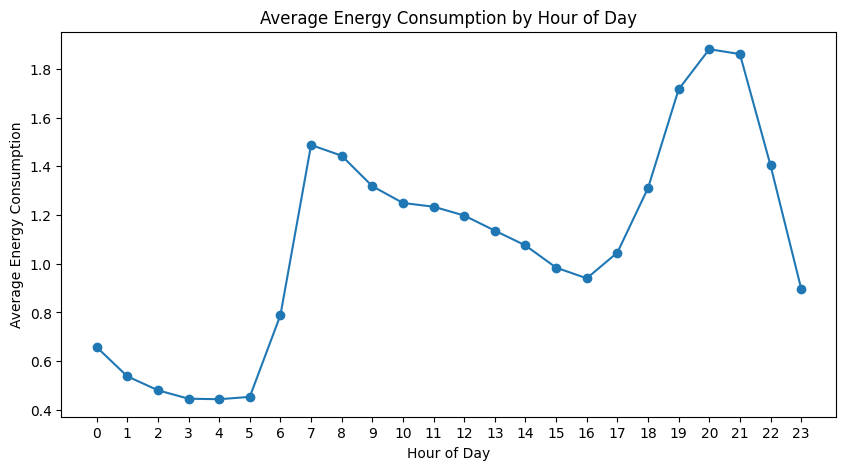

In [22]:
hourly_pattern = feature_df.groupby("hour")["energy_consumption"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption")
plt.xticks(range(0, 24))
plt.show()

---

## Average Energy Consumption by Day of Week

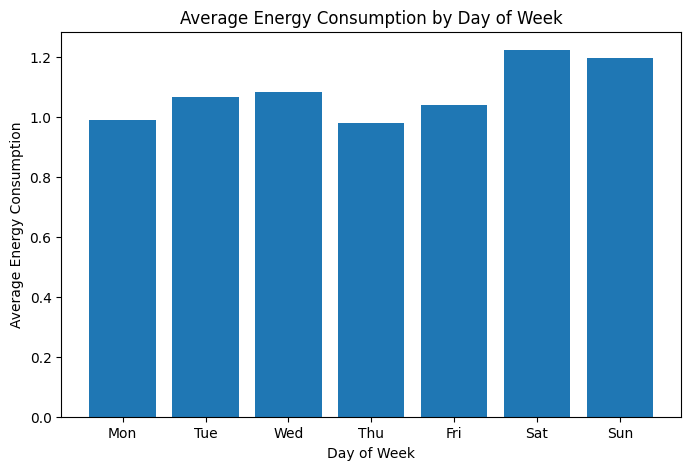

In [23]:
weekday_pattern = feature_df.groupby("day_of_week")["energy_consumption"].mean()

plt.figure(figsize=(8, 5))
plt.bar(weekday_pattern.index, weekday_pattern.values)
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption")
plt.xticks(
    ticks=range(7),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.show()

---

## Weekday vs Weekend Consumption

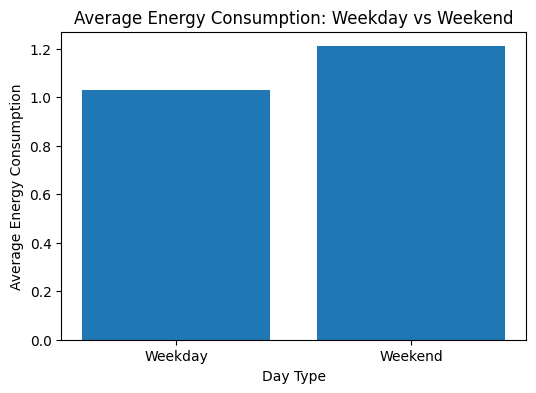

In [24]:
weekend_pattern = feature_df.groupby("is_weekend")["energy_consumption"].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Weekday", "Weekend"], weekend_pattern.values)
plt.title("Average Energy Consumption: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Energy Consumption")
plt.show()

---

# **9. Train-Test Split**

We will use the latest **7 days** as the test set.

Since this is time-series data, we do **not** use random train-test splitting.

---

## Prepare Train and Test Data

In [25]:
# Forecast horizon: last 7 days of hourly data
forecast_horizon = 24 * 7

train_df = hourly_df.iloc[:-forecast_horizon]
test_df = hourly_df.iloc[-forecast_horizon:]

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)
print("Test start date:", test_df.index.min())
print("Test end date:", test_df.index.max())

Training data: (34421, 1)
Testing data: (168, 1)
Test start date: 2010-11-19 22:00:00
Test end date: 2010-11-26 21:00:00


---

# **10. Evaluation Function**

## Define Evaluation Metrics

In [26]:
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error.
    A small value is added to avoid division by zero.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecasting model using MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"{model_name} Performance")
    print("=" * 40)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("MAPE:", round(mape, 2), "%")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

---

# **11. Model 1 — ARIMA**

ARIMA is a classical statistical model used for time-series forecasting.

Because ARIMA can be slow on very large datasets, we will train it on the most recent portion of the training data.

---

## Train ARIMA Model

In [27]:
# Use recent data to reduce training time
arima_train = train_df["energy_consumption"].iloc[-24*60:]

# Train ARIMA model
arima_model = ARIMA(
    arima_train,
    order=(2, 1, 2)
)

arima_result = arima_model.fit()

# Forecast next 7 days
arima_forecast = arima_result.forecast(steps=forecast_horizon)

# Convert forecast to Series with test index
arima_forecast = pd.Series(
    arima_forecast.values,
    index=test_df.index,
    name="ARIMA_Forecast"
)

arima_forecast.head()

,ARIMA_Forecast
datetime,
2010-11-19 22:00:00,1.576885
2010-11-19 23:00:00,1.455685
2010-11-20 00:00:00,1.370050
2010-11-20 01:00:00,1.320171
2010-11-20 02:00:00,1.283565


---

## Evaluate ARIMA

In [28]:
arima_results = evaluate_forecast(
    test_df["energy_consumption"],
    arima_forecast,
    "ARIMA"
)

ARIMA Performance
MAE: 0.6982
RMSE: 0.8587
MAPE: 123.29 %


---

## Plot ARIMA Forecast

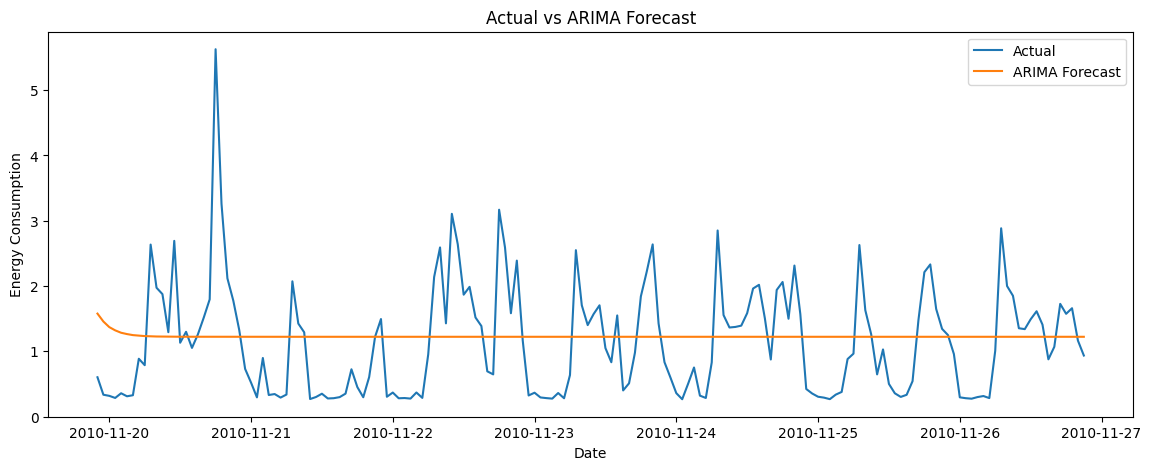

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(test_df.index, test_df["energy_consumption"], label="Actual")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.title("Actual vs ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

---

# **12. Model 2 — Prophet**

Prophet is useful for time-series forecasting with trend and seasonality.

Prophet requires two columns:

| Column | Meaning          |
| ------ | ---------------- |
| ds     | Date/time column |
| y      | Target value     |

---

## Prepare Data for Prophet

In [30]:
# Prepare Prophet training data
prophet_train = train_df.reset_index().rename(columns={
    "datetime": "ds",
    "energy_consumption": "y"
})

# If index name is missing, fix column name
prophet_train.columns = ["ds", "y"]

prophet_test = test_df.reset_index().rename(columns={
    "datetime": "ds",
    "energy_consumption": "y"
})

prophet_test.columns = ["ds", "y"]

prophet_train.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


---

## Train Prophet Model

In [31]:
# Initialize Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

# Fit model
prophet_model.fit(prophet_train)

---

## Forecast Using Prophet

In [32]:
# Create future dataframe for test period
future = prophet_model.make_future_dataframe(
    periods=forecast_horizon,
    freq="H"
)

# Generate forecast
prophet_forecast_full = prophet_model.predict(future)

# Extract only test period forecast
prophet_forecast = prophet_forecast_full.tail(forecast_horizon)

# Convert forecast into Series
prophet_pred = pd.Series(
    prophet_forecast["yhat"].values,
    index=test_df.index,
    name="Prophet_Forecast"
)

prophet_pred.head()

,Prophet_Forecast
datetime,
2010-11-19 22:00:00,1.109764
2010-11-19 23:00:00,0.689199
2010-11-20 00:00:00,0.414851
2010-11-20 01:00:00,0.295889
2010-11-20 02:00:00,0.235266


---

## Evaluate Prophet

In [33]:
prophet_results = evaluate_forecast(
    test_df["energy_consumption"],
    prophet_pred,
    "Prophet"
)

Prophet Performance
MAE: 0.5217
RMSE: 0.767
MAPE: 53.6 %


---

## Plot Prophet Forecast

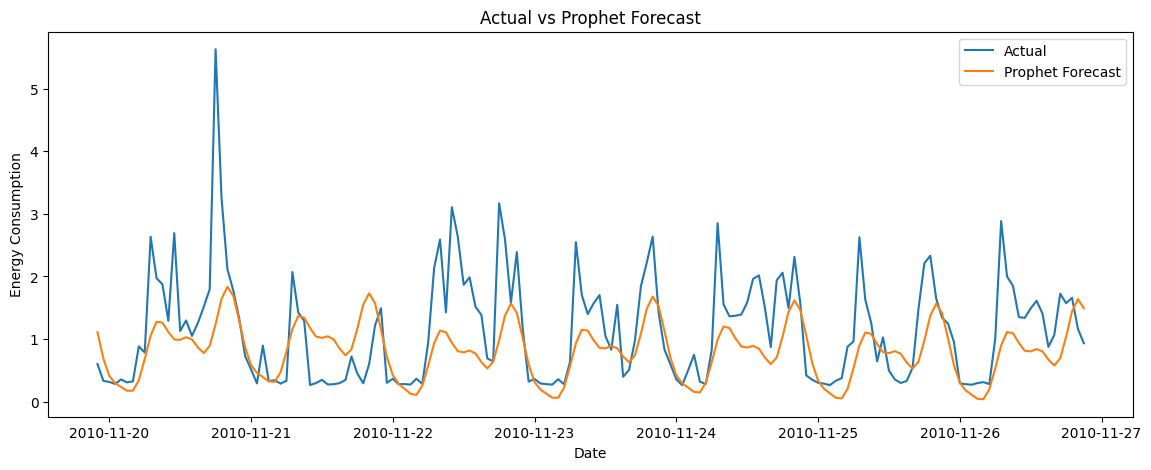

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(test_df.index, test_df["energy_consumption"], label="Actual")
plt.plot(prophet_pred.index, prophet_pred, label="Prophet Forecast")
plt.title("Actual vs Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

---

# **13. Model 3 — XGBoost**

XGBoost is a machine learning model.
Unlike ARIMA and Prophet, XGBoost does not understand time automatically.

So we give it time-based features:

* Hour
* Day of week
* Month
* Weekend indicator
* Lag features
* Rolling average features

---

## Prepare XGBoost Features

In [35]:
# Use the feature-engineered dataset
xgb_df = feature_df.copy()

# Define features and target
xgb_features = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_24_mean",
    "rolling_168_mean"
]

target = "energy_consumption"

# Split according to same forecast horizon
xgb_train = xgb_df.iloc[:-forecast_horizon]
xgb_test = xgb_df.iloc[-forecast_horizon:]

X_train = xgb_train[xgb_features]
y_train = xgb_train[target]

X_test = xgb_test[xgb_features]
y_test = xgb_test[target]

print("XGBoost training data:", X_train.shape)
print("XGBoost testing data:", X_test.shape)

XGBoost training data: (34253, 11)
XGBoost testing data: (168, 11)


---

## Train XGBoost Model

In [36]:
# Initialize XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

---

## Forecast Using XGBoost

In [37]:
# Predict on test set
xgb_forecast = xgb_model.predict(X_test)

# Convert to Series
xgb_pred = pd.Series(
    xgb_forecast,
    index=xgb_test.index,
    name="XGBoost_Forecast"
)

xgb_pred.head()

,XGBoost_Forecast
datetime,
2010-11-19 22:00:00,1.424072
2010-11-19 23:00:00,0.441399
2010-11-20 00:00:00,0.410164
2010-11-20 01:00:00,0.394387
2010-11-20 02:00:00,0.384759


---

## Evaluate XGBoost

In [38]:
xgb_results = evaluate_forecast(
    y_test,
    xgb_pred,
    "XGBoost"
)

XGBoost Performance
MAE: 0.3581
RMSE: 0.5487
MAPE: 44.58 %


---

## Plot XGBoost Forecast

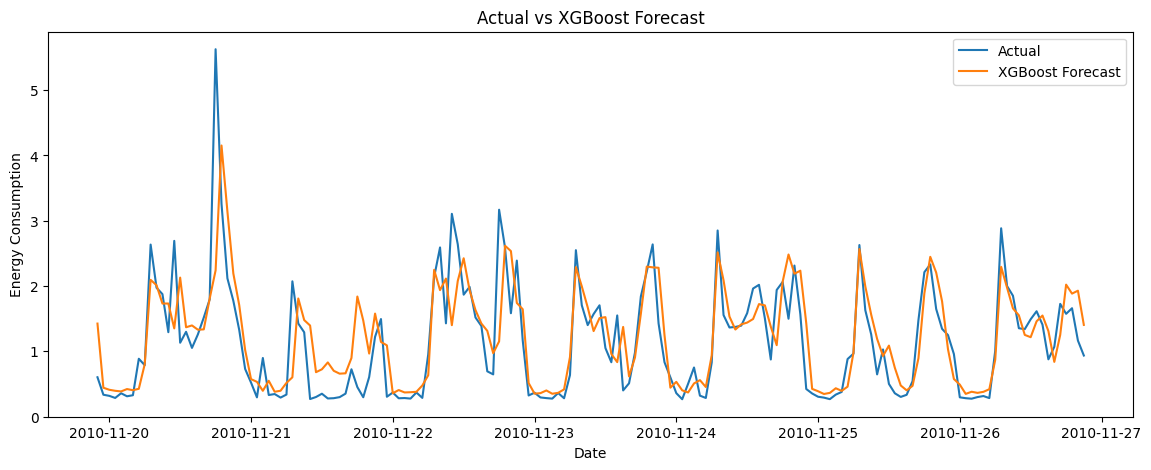

In [39]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(xgb_pred.index, xgb_pred, label="XGBoost Forecast")
plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

---

# **14. Model Performance Comparison**

## Compare ARIMA, Prophet, and XGBoost

In [40]:
# Combine results
results_df = pd.DataFrame([
    arima_results,
    prophet_results,
    xgb_results
])

results_df

,Model,MAE,RMSE,MAPE
0,ARIMA,0.698232,0.858736,123.285384
1,Prophet,0.521711,0.766975,53.598747
2,XGBoost,0.358131,0.548702,44.582018


---

## Plot Model Comparison

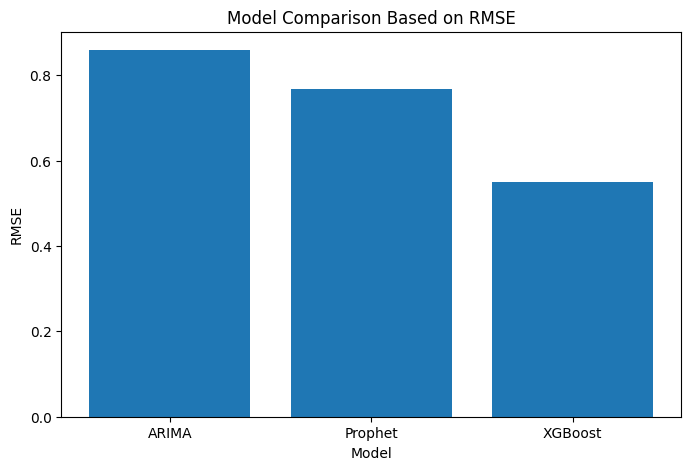

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

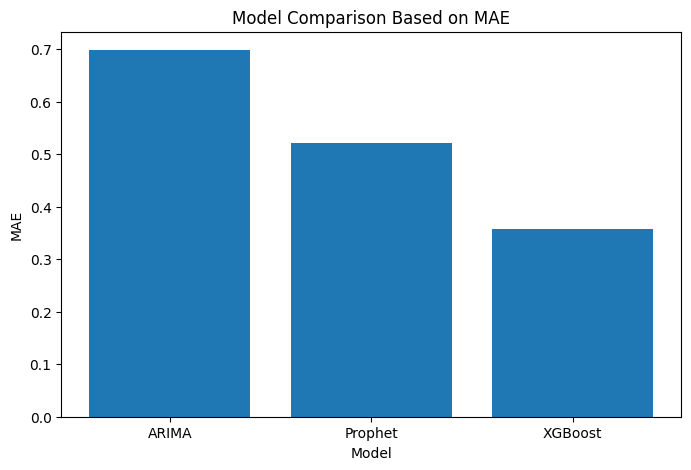

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

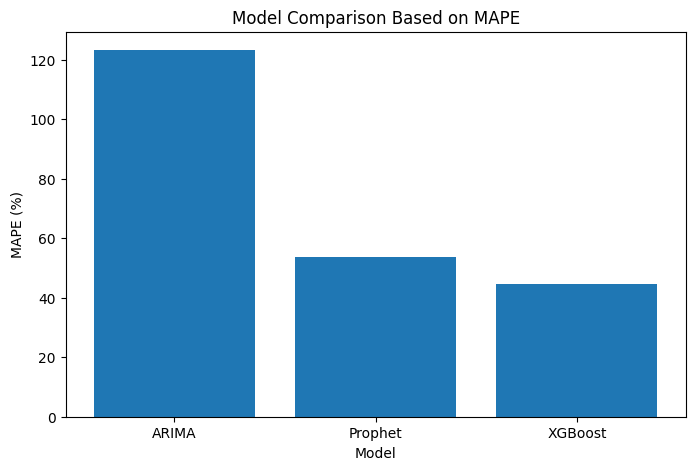

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAPE"])
plt.title("Model Comparison Based on MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.show()

---

# **15. Plot Actual vs All Forecasts**

## Combined Forecast Visualization

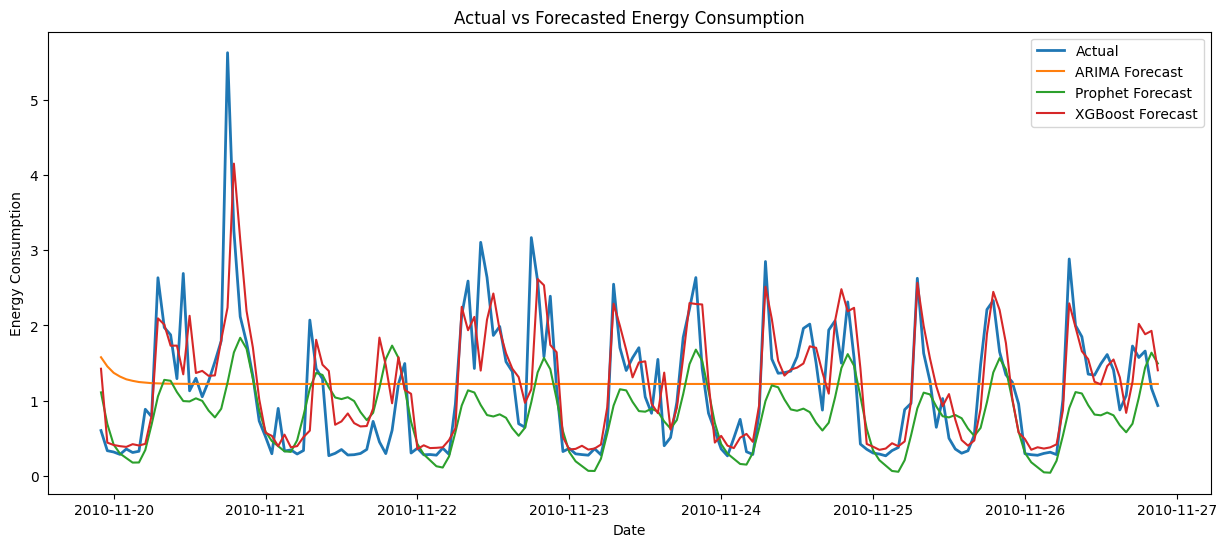

In [44]:
plt.figure(figsize=(15, 6))

plt.plot(test_df.index, test_df["energy_consumption"], label="Actual", linewidth=2)
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.plot(prophet_pred.index, prophet_pred, label="Prophet Forecast")
plt.plot(xgb_pred.index, xgb_pred, label="XGBoost Forecast")

plt.title("Actual vs Forecasted Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

---

# **16. XGBoost Feature Importance**

## Plot Feature Importance

In [45]:
# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": xgb_features,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,lag_1,0.516593
0,hour,0.116086
8,lag_168,0.070717
4,is_weekend,0.068101
9,rolling_24_mean,0.053151
1,day_of_week,0.037107
6,lag_24,0.035906
10,rolling_168_mean,0.031492
7,lag_48,0.029440
3,month,0.023058


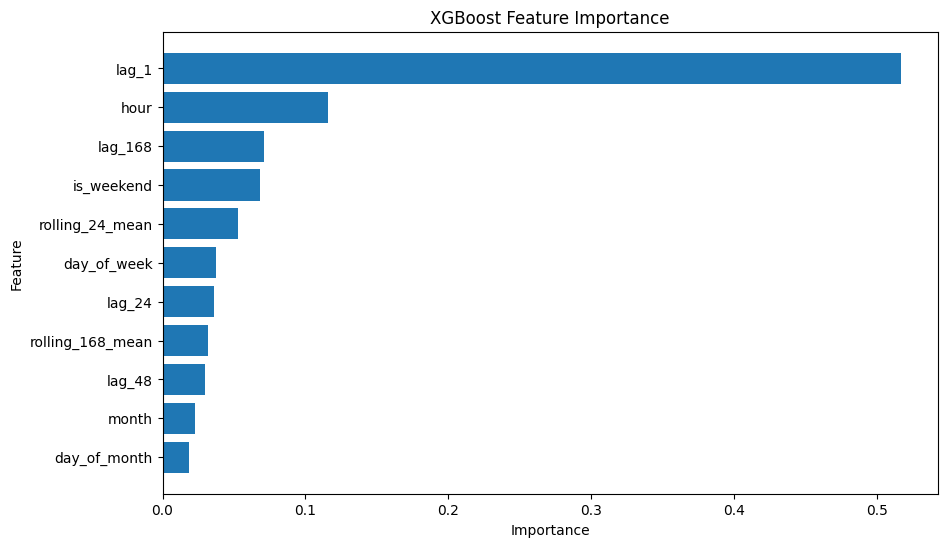

In [46]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

---

# **17. Final Conclusion with Insights**

Final Conclusion:

This project forecasted short-term household energy consumption using the Household Power Consumption Dataset.

The original dataset contained minute-level electricity usage data. The Date and Time columns were parsed
into a proper datetime index, and the data was resampled into hourly average energy consumption.
Missing values were handled using forward fill and backward fill.

Exploratory Data Analysis showed that household energy consumption changes over time and follows visible
daily and weekly patterns. Energy usage can vary by hour of the day, day of the week, and weekend behavior.

Time-based features were engineered, including:
- Hour of day
- Day of week
- Day of month
- Month
- Weekend indicator
- Lag features
- Rolling average features

Three forecasting models were compared:

1. ARIMA:
   ARIMA is a classical time-series forecasting model. It can capture trend and autocorrelation,
   but it may struggle with complex nonlinear behavior and large datasets.

2. Prophet:
   Prophet is useful for modeling trend and seasonality. It can capture daily and weekly patterns
   and is easier to use for business forecasting problems.

3. XGBoost:
   XGBoost performed forecasting as a supervised regression problem using time-based, lag, and rolling
   features. It can capture nonlinear relationships and often performs well when strong feature engineering
   is used.

The models were evaluated using:
- MAE
- RMSE
- MAPE

The best model should be selected based on the lowest MAE, RMSE, and MAPE values.

In most practical cases, XGBoost is expected to perform strongly because it uses lag features and rolling
average features. However, Prophet may be more interpretable for seasonality, while ARIMA is useful as a
classical statistical baseline.

Overall, this project shows that household electricity usage can be forecasted using historical time-based
patterns. Such forecasting can help with energy planning, demand management, cost optimization, and better
household electricity usage decisions.
